# Noisy Observation Evaluation for `HexnerGame` (Amortized)

This notebook evaluates a pretrained amortized policy under **state-observation noise**.

Setup:
- P1 observes `y_t = x_t + noise_t`.
- At each step, P1 **re-solves** the primal game from `(y_t, p_t)`.
- P2 control is computed from the same local solve, using true state by default.
- Compare against exact-observation receding-horizon baseline.

This directly tests deployment-time robustness to noisy state observations (not prior-shift adaptation).


In [30]:
import os
import sys
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Add repo root to path (works from notebooks/ or repo root)
CWD = os.getcwd()
if os.path.basename(CWD) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(CWD, ".."))
else:
    REPO_ROOT = CWD
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)


Repo root: /Users/mghimire/Research/MPC_2p0s1


In [31]:
from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.games.hexner_game import HexnerGame, HexnerParams
import MPC_2p0s1.outer_opt.amortized_alpha as amortized_alpha_mod
from MPC_2p0s1.outer_opt.amortized_alpha import (
    AmortizedAlphaConfig,
    AmortizedAlphaParam,
    primal_objective_from_alpha,
)
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.tree.rollout import rollout_trajectory


In [32]:
# Runtime config

device = torch.device("cpu")
CHECKPOINT_PATH = project_relative("runs/hexner_amortized/latest.pt")

print(f"Checkpoint: {CHECKPOINT_PATH}")


def _resolve_dtype(dtype_obj):
    if isinstance(dtype_obj, torch.dtype):
        return dtype_obj
    if isinstance(dtype_obj, str):
        key = dtype_obj.replace("torch.", "")
        if hasattr(torch, key):
            return getattr(torch, key)
    return torch.float32


def _rebuild_game_config(meta_dict: Dict) -> GameConfig:
    cfg = GameConfig()
    for k, v in meta_dict.items():
        setattr(cfg, k, v)

    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K

    cfg.device = str(device)
    cfg.device_resolved = device
    cfg.dtype = _resolve_dtype(getattr(cfg, "dtype", torch.float32))
    return cfg


def _parse_tuple_floats(raw):
    if isinstance(raw, (list, tuple)):
        return tuple(float(v) for v in raw)
    return tuple(float(v.strip()) for v in str(raw).split(",") if v.strip())


def _parse_tuple_ints(raw):
    if isinstance(raw, (list, tuple)):
        return tuple(int(v) for v in raw)
    return tuple(int(v.strip()) for v in str(raw).split(",") if v.strip())


Checkpoint: /Users/mghimire/Research/MPC_2p0s1/runs/hexner_amortized/latest.pt


In [33]:
payload = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
meta = payload.get("meta", {})
args_ckpt = meta.get("args", {})

if "model_state_dict" not in payload:
    raise RuntimeError(
        "Checkpoint does not contain 'model_state_dict'. "
        "Use a checkpoint produced by train_hexner_amortized.py."
    )

game_cfg = _rebuild_game_config(meta.get("game_config", {}))
indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)

hidden_dims = _parse_tuple_ints(args_ckpt.get("hidden_dims", "256,256"))
amort_cfg = AmortizedAlphaConfig(
    hidden_dims=hidden_dims,
    activation=str(args_ckpt.get("activation", "silu")),
    dropout=float(args_ckpt.get("dropout", 0.0)),
)

model = AmortizedAlphaParam(
    indexer=indexer,
    dx=game_cfg.dx,
    I=game_cfg.I,
    cfg=amort_cfg,
    dtype=game_cfg.dtype,
    device=device,
)
model.load_state_dict(payload["model_state_dict"])
model.eval()

params = HexnerParams(
    theta_values=_parse_tuple_floats(args_ckpt.get("theta_values", "-1.0,1.0")),
    target_z=None,
    R1_scale=float(args_ckpt.get("R1_scale", 1.0)),
    R2_scale=float(args_ckpt.get("R2_scale", 1.0)),
    K1_scale=float(args_ckpt.get("K1_scale", 1.0)),
    K2_scale=float(args_ckpt.get("K2_scale", 1.0)),
)

game = HexnerGame(cfg=game_cfg, params=params, prior=None)
action_space = BoxActionSpace.from_config(game_cfg)

# Notebook compatibility if riccati_backward is decorated with torch.compile
if hasattr(amortized_alpha_mod.riccati_backward, "__wrapped__"):
    amortized_alpha_mod.riccati_backward = amortized_alpha_mod.riccati_backward.__wrapped__
    print("Patched to uncompiled riccati_backward for notebook compatibility.")

print(
    f"Loaded checkpoint: step={meta.get('step', '?')}, "
    f"train_loss={meta.get('train_loss', '?')}, eval_loss={meta.get('eval_loss', '?')}"
)
print(f"Game: I={game_cfg.I}, K={game_cfg.K}, T={game_cfg.T}, dtype={game_cfg.dtype}")
print(f"Model: hidden_dims={hidden_dims}, activation={amort_cfg.activation}, dropout={amort_cfg.dropout}")


Loaded checkpoint: step=1999, train_loss=-0.30411601066589355, eval_loss=-0.33059778809547424
Game: I=2, K=10, T=1.0, dtype=torch.float32
Model: hidden_dims=(64,), activation=silu, dropout=0.0


In [60]:

dtype = game_cfg.dtype
base_x0 = game.default_initial_state().to(device=device, dtype=dtype)

def make_x0(
    p1x=-1.0, p1y=0.0, p1vx=0.0, p1vy=0.0,
    p2x=1.0, p2y=0.0, p2vx=0.0, p2vy=0.0,
):
    return torch.tensor(
        [p1x, p1y, p1vx, p1vy, p2x, p2y, p2vx, p2vy],
        device=device,
        dtype=dtype,
    )

x0_center = base_x0.clone()
x0_topright = make_x0(p1x=0.2, p1y=0.6, p2x=1.2, p2y=0.8)

scenarios: List[Dict] = [
    {"name": "S0 balanced_center", "prior": torch.tensor([0.5, 0.5], device=device, dtype=dtype), "x0": x0_center},
    {"name": "S1 rare_type0_center", "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype), "x0": x0_center},
    {"name": "S2 rare_type0_topright", "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype), "x0": x0_topright},
    {"name": "S3 common_type0_topright", "prior": torch.tensor([0.1, 0.9], device=device, dtype=dtype), "x0": x0_topright},
]

# Noise configuration
OBS_NOISE_STD = 0.5 #0.05
OBS_NOISE_MODE = "pos_only"  # one of: "none", "pos_only", "all"
NUM_NOISE_TRIALS = 1
BASE_NOISE_SEED = 123

# Control configuration
P2_USES_TRUE_STATE = True
SAMPLE_ACTIONS = False  # argmax over alpha for deterministic policy branch

# Online alpha optimization on remaining subtree at each step
ONLINE_ALPHA_ITERS = 10
ONLINE_ALPHA_LR = 1e-1
ONLINE_ALPHA_EARLY_STOP = True
ONLINE_ALPHA_MIN_ITERS = 5
ONLINE_ALPHA_PATIENCE = 3
ONLINE_ALPHA_MIN_DELTA = 1e-4

# Which baseline to use in trajectory/belief plots:
#   "existing" -> one-shot rollout_trajectory (matches existing notebooks)
#   "replan"   -> zero-noise re-solve each step on remaining subtree
EXACT_REFERENCE = "replan"
if EXACT_REFERENCE not in {"existing", "replan"}:
    raise ValueError(f"EXACT_REFERENCE must be 'existing' or 'replan' (got {EXACT_REFERENCE})")

print(f"OBS_NOISE_STD={OBS_NOISE_STD}, OBS_NOISE_MODE={OBS_NOISE_MODE}")
print(f"NUM_NOISE_TRIALS={NUM_NOISE_TRIALS}, BASE_NOISE_SEED={BASE_NOISE_SEED}")
print(f"P2_USES_TRUE_STATE={P2_USES_TRUE_STATE}, SAMPLE_ACTIONS={SAMPLE_ACTIONS}")
print(
    f"ONLINE_ALPHA_ITERS={ONLINE_ALPHA_ITERS}, ONLINE_ALPHA_LR={ONLINE_ALPHA_LR}, "
    f"early_stop={ONLINE_ALPHA_EARLY_STOP}, min_iters={ONLINE_ALPHA_MIN_ITERS}, "
    f"patience={ONLINE_ALPHA_PATIENCE}, min_delta={ONLINE_ALPHA_MIN_DELTA}"
)
print(f"EXACT_REFERENCE={EXACT_REFERENCE}")
for s in scenarios:
    print(f"  {s['name']}: prior={s['prior'].tolist()}")


OBS_NOISE_STD=0.5, OBS_NOISE_MODE=pos_only
NUM_NOISE_TRIALS=1, BASE_NOISE_SEED=123
P2_USES_TRUE_STATE=True, SAMPLE_ACTIONS=False
ONLINE_ALPHA_ITERS=10, ONLINE_ALPHA_LR=0.1, early_stop=True, min_iters=5, patience=3, min_delta=0.0001
EXACT_REFERENCE=replan
  S0 balanced_center: prior=[0.5, 0.5]
  S1 rare_type0_center: prior=[0.8999999761581421, 0.10000000149011612]
  S2 rare_type0_topright: prior=[0.8999999761581421, 0.10000000149011612]
  S3 common_type0_topright: prior=[0.10000000149011612, 0.8999999761581421]


In [61]:

def make_observation_mask(game, mode: str) -> torch.Tensor:
    mode = str(mode).lower()
    mask = torch.zeros(game.dx, device=game.device_resolved, dtype=game.dtype)
    if mode in ("none", "no_noise"):
        return mask
    if mode == "all":
        return torch.ones_like(mask)
    if mode == "pos_only":
        mask[0:2] = 1.0
        mask[game.cfg.dx1 : game.cfg.dx1 + 2] = 1.0
        return mask
    raise ValueError(f"Unknown OBS_NOISE_MODE={mode}")


def rollout_total_cost(game, x_traj, u_traj, v_traj, type_index: int) -> float:
    R_i = game.R[type_index]
    S_i = game.S[type_index]
    tau = float(game.cfg.tau)
    run_u = 0.5 * tau * torch.einsum("kd,dd,kd->k", u_traj, R_i, u_traj)
    run_v = 0.5 * tau * torch.einsum("kd,dd,kd->k", v_traj, S_i, v_traj)
    running = (run_u - run_v).sum()
    terminal = game.terminal_cost_type(type_index, x_traj[-1])
    return float((running + terminal).detach().cpu().item())


def summarize_adaptation_diag(step_diags: List[Dict]) -> Dict:
    if len(step_diags) == 0:
        return {
            "mean_delta_loss": 0.0,
            "improved_fraction": 0.0,
            "converged_fraction": 0.0,
            "mean_iters": 0.0,
        }
    deltas = np.asarray([float(d["final_loss"] - d["warm_loss"]) for d in step_diags], dtype=np.float64)
    improved = np.asarray([1.0 if float(d["final_loss"] - d["warm_loss"]) < -1e-10 else 0.0 for d in step_diags], dtype=np.float64)
    converged = np.asarray([1.0 if bool(d.get("converged", False)) else 0.0 for d in step_diags], dtype=np.float64)
    iters = np.asarray([float(d.get("iters_run", 0)) for d in step_diags], dtype=np.float64)
    return {
        "mean_delta_loss": float(deltas.mean()),
        "improved_fraction": float(improved.mean()),
        "converged_fraction": float(converged.mean()),
        "mean_iters": float(iters.mean()),
    }


def rebase_alpha_to_remaining(
    alpha_full: torch.Tensor,
    indexer_full: FullIaryTreeIndexer,
    actions: List[int],
) -> tuple[torch.Tensor, FullIaryTreeIndexer]:
    I = indexer_full.I
    K_full = indexer_full.K
    t = len(actions)
    K_rem = K_full - t
    if K_rem <= 0:
        raise ValueError(f"No remaining horizon: K_full={K_full}, actions={t}")

    indexer_rem = FullIaryTreeIndexer(I=I, K=K_rem)
    alpha_rem = alpha_full.new_zeros((K_rem, indexer_rem.max_nodes_per_depth, I, I))

    base = 0
    for a in actions:
        base = base * I + int(a)

    for d in range(K_rem):
        num_nodes = indexer_rem.node_count(d)
        for new_node in range(num_nodes):
            old_node = base * (I ** d) + new_node
            alpha_rem[d, new_node] = alpha_full[t + d, old_node]

    return alpha_rem, indexer_rem


def optimize_remaining_alpha(
    game,
    alpha_init: torch.Tensor,
    indexer_rem: FullIaryTreeIndexer,
    action_space,
    x0: torch.Tensor,
    p0: torch.Tensor,
    num_iters: int,
    lr: float,
    use_early_stop: bool,
    min_iters: int,
    patience: int,
    min_delta: float,
):
    # Evaluate warm-start loss once.
    with torch.no_grad():
        warm_loss_t = primal_objective_from_alpha(
            game=game,
            alpha=alpha_init,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=False,
        )
    warm_loss = float(warm_loss_t.detach().cpu().item())

    if int(num_iters) <= 0:
        with torch.no_grad():
            final_loss_t, final_details = primal_objective_from_alpha(
                game=game,
                alpha=alpha_init,
                indexer=indexer_rem,
                x0=x0,
                p0=p0,
                action_space=action_space,
                return_details=True,
            )
        final_loss = float(final_loss_t.detach().cpu().item())
        diag = {
            "warm_loss": warm_loss,
            "final_loss": final_loss,
            "iters_run": 0,
            "early_stopped": False,
            "converged": False,
            "loss_curve": [final_loss],
        }
        return alpha_init, final_details, diag

    logits = torch.nn.Parameter(torch.log(alpha_init.clamp_min(1e-8)))
    optimizer = torch.optim.Adam([logits], lr=float(lr))

    losses: List[float] = []
    prev = None
    stable_steps = 0
    early_stopped = False

    for _ in range(int(num_iters)):
        optimizer.zero_grad()
        alpha_it = torch.softmax(logits, dim=-1)
        loss_it = primal_objective_from_alpha(
            game=game,
            alpha=alpha_it,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=False,
        )
        loss_it.backward()
        optimizer.step()

        cur = float(loss_it.detach().cpu().item())
        losses.append(cur)

        if prev is not None and abs(cur - prev) <= float(min_delta):
            stable_steps += 1
        else:
            stable_steps = 0
        prev = cur

        if bool(use_early_stop) and len(losses) >= int(min_iters) and stable_steps >= int(patience):
            early_stopped = True
            break

    alpha_final = torch.softmax(logits.detach(), dim=-1)
    with torch.no_grad():
        final_loss_t, final_details = primal_objective_from_alpha(
            game=game,
            alpha=alpha_final,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=True,
        )
    final_loss = float(final_loss_t.detach().cpu().item())

    converged = bool(
        early_stopped
        or (len(losses) >= 2 and abs(losses[-1] - losses[-2]) <= float(min_delta))
    )

    diag = {
        "warm_loss": warm_loss,
        "final_loss": final_loss,
        "iters_run": len(losses),
        "early_stopped": bool(early_stopped),
        "converged": converged,
        "loss_curve": losses,
    }
    return alpha_final, final_details, diag


def rollout_existing_once(
    game,
    model,
    indexer,
    action_space,
    x0,
    p0,
    type_index,
    sample_actions=False,
    seed=0,
):
    device = game.device_resolved
    dtype = game.dtype
    x0 = x0.to(device=device, dtype=dtype)
    p0 = p0.to(device=device, dtype=dtype)

    with torch.no_grad():
        alpha_tree = model.single_alpha(x0=x0, p0=p0)

    _, details = primal_objective_from_alpha(
        game=game,
        alpha=alpha_tree,
        indexer=indexer,
        x0=x0,
        p0=p0,
        action_space=action_space,
        return_details=True,
    )

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    ro = rollout_trajectory(
        game=game,
        indexer=indexer,
        belief_tree=details["belief_tree"],
        riccati_sol=details["riccati_solution"],
        alpha=alpha_tree,
        x0=x0,
        type_index=type_index,
        action_space=action_space,
        sample_actions=sample_actions,
        generator=g,
    )

    return {
        "x_traj": ro.x_traj,
        "y_traj": ro.x_traj[:-1],
        "u_traj": ro.u_traj,
        "v_traj": ro.v_traj,
        "belief_traj": ro.belief_traj,
        "proto_indices": ro.proto_indices,
        "num_replans": 1,
        "adaptation_diag": [],
        "adaptation_summary": summarize_adaptation_diag([]),
    }


def rollout_replan_remaining_tree(
    game,
    alpha_full,
    indexer_full,
    action_space,
    x0,
    p0,
    type_index,
    obs_noise_std: float,
    obs_mask: torch.Tensor,
    seed: int,
    sample_actions: bool = False,
    p2_uses_true_state: bool = True,
    online_alpha_iters: int = 0,
    online_alpha_lr: float = 5e-2,
    online_alpha_early_stop: bool = True,
    online_alpha_min_iters: int = 5,
    online_alpha_patience: int = 3,
    online_alpha_min_delta: float = 1e-5,
):
    K_full = indexer_full.K
    device = game.device_resolved
    dtype = game.dtype

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    x = x0.to(device=device, dtype=dtype)
    p = p0.to(device=device, dtype=dtype)

    actions_so_far: List[int] = []
    x_traj = [x.clone()]
    y_traj = []
    u_traj = []
    v_traj = []
    belief_traj = [p.clone()]
    proto_indices = []
    step_adaptation_diag: List[Dict] = []

    for _t in range(K_full):
        eps = torch.randn(game.dx, generator=g, device=device, dtype=dtype) * float(obs_noise_std)
        y = x + eps * obs_mask
        y_traj.append(y.clone())

        alpha_rem_init, indexer_rem = rebase_alpha_to_remaining(alpha_full, indexer_full, actions_so_far)

        alpha_rem_opt, details, step_diag = optimize_remaining_alpha(
            game=game,
            alpha_init=alpha_rem_init,
            indexer_rem=indexer_rem,
            action_space=action_space,
            x0=y,
            p0=p,
            num_iters=int(online_alpha_iters),
            lr=float(online_alpha_lr),
            use_early_stop=bool(online_alpha_early_stop),
            min_iters=int(online_alpha_min_iters),
            patience=int(online_alpha_patience),
            min_delta=float(online_alpha_min_delta),
        )
        step_adaptation_diag.append(step_diag)

        alpha_row = alpha_rem_opt[0, 0, type_index]
        if sample_actions:
            dist = torch.distributions.Categorical(probs=alpha_row)
            a = int(dist.sample().item())
        else:
            a = int(torch.argmax(alpha_row).item())

        proto_indices.append(a)
        actions_so_far.append(a)

        riccati_sol = details["riccati_solution"]
        belief_tree = details["belief_tree"]

        K_u_edge = riccati_sol.K_u[0][0, a]
        K_v_edge = riccati_sol.K_v[0][0, a]
        lam_edge = belief_tree.lambda_edge[0][0]
        kappa_u_all = riccati_sol.kappa_u[0][0]
        kappa_v_all = riccati_sol.kappa_v[0][0]
        kappa_u_agg = torch.einsum("a,ad->d", lam_edge, kappa_u_all)
        kappa_v_agg = torch.einsum("a,ad->d", lam_edge, kappa_v_all)

        u = K_u_edge @ y + kappa_u_agg
        v_state = x if p2_uses_true_state else y
        v = K_v_edge @ v_state + kappa_v_agg

        u = action_space.clip_u(u)
        v = action_space.clip_v(v)

        u_traj.append(u.clone())
        v_traj.append(v.clone())

        x = game.step_dynamics(x, u, v)
        x_traj.append(x.clone())

        p = belief_tree.beliefs[1][a]
        belief_traj.append(p.clone())

    x_traj = torch.stack(x_traj, dim=0)
    y_traj = torch.stack(y_traj, dim=0)
    u_traj = torch.stack(u_traj, dim=0)
    v_traj = torch.stack(v_traj, dim=0)
    belief_traj = torch.stack(belief_traj, dim=0)
    proto_indices = torch.tensor(proto_indices, dtype=torch.long, device=device)

    return {
        "x_traj": x_traj,
        "y_traj": y_traj,
        "u_traj": u_traj,
        "v_traj": v_traj,
        "belief_traj": belief_traj,
        "proto_indices": proto_indices,
        "num_replans": int(len(proto_indices)),
        "adaptation_diag": step_adaptation_diag,
        "adaptation_summary": summarize_adaptation_diag(step_adaptation_diag),
    }


In [62]:

obs_mask = make_observation_mask(game, OBS_NOISE_MODE)
print("Observation mask:", obs_mask.detach().cpu().tolist())

scenario_results = {}
summary_rows = []

for s_idx, s in enumerate(scenarios):
    name = s["name"]
    prior = s["prior"]
    x0 = s["x0"]

    print("=" * 88)
    print(f"Running {name} | prior={prior.tolist()}")

    scenario_results[name] = {
        "prior": prior,
        "x0": x0,
        "exact": {},
        "exact_replan": {},
        "noisy_trials": {},
        "noisy_stats": {},
    }

    with torch.no_grad():
        alpha_full = model.single_alpha(x0=x0, p0=prior)

    for type_idx in range(game.I):
        ro_exact_existing = rollout_existing_once(
            game=game,
            model=model,
            indexer=indexer,
            action_space=action_space,
            x0=x0,
            p0=prior,
            type_index=type_idx,
            sample_actions=SAMPLE_ACTIONS,
            seed=0,
        )
        exact_cost = rollout_total_cost(
            game,
            ro_exact_existing["x_traj"],
            ro_exact_existing["u_traj"],
            ro_exact_existing["v_traj"],
            type_idx,
        )

        ro_exact_replan = rollout_replan_remaining_tree(
            game=game,
            alpha_full=alpha_full,
            indexer_full=indexer,
            action_space=action_space,
            x0=x0,
            p0=prior,
            type_index=type_idx,
            obs_noise_std=0.0,
            obs_mask=obs_mask,
            seed=0,
            sample_actions=SAMPLE_ACTIONS,
            p2_uses_true_state=P2_USES_TRUE_STATE,
            online_alpha_iters=ONLINE_ALPHA_ITERS,
            online_alpha_lr=ONLINE_ALPHA_LR,
            online_alpha_early_stop=ONLINE_ALPHA_EARLY_STOP,
            online_alpha_min_iters=ONLINE_ALPHA_MIN_ITERS,
            online_alpha_patience=ONLINE_ALPHA_PATIENCE,
            online_alpha_min_delta=ONLINE_ALPHA_MIN_DELTA,
        )
        if ro_exact_replan["num_replans"] != int(game.cfg.K):
            raise RuntimeError(
                f"Exact replan expected {int(game.cfg.K)} re-solves, got {ro_exact_replan['num_replans']}"
            )
        exact_replan_cost = rollout_total_cost(
            game,
            ro_exact_replan["x_traj"],
            ro_exact_replan["u_traj"],
            ro_exact_replan["v_traj"],
            type_idx,
        )

        noisy_trials = []
        noisy_costs = []
        noisy_step_delta_means = []
        noisy_step_converged_fracs = []
        noisy_step_improved_fracs = []

        for trial in range(int(NUM_NOISE_TRIALS)):
            ro_noisy = rollout_replan_remaining_tree(
                game=game,
                alpha_full=alpha_full,
                indexer_full=indexer,
                action_space=action_space,
                x0=x0,
                p0=prior,
                type_index=type_idx,
                obs_noise_std=float(OBS_NOISE_STD),
                obs_mask=obs_mask,
                seed=int(BASE_NOISE_SEED + 10000 * s_idx + 100 * type_idx + trial),
                sample_actions=SAMPLE_ACTIONS,
                p2_uses_true_state=P2_USES_TRUE_STATE,
                online_alpha_iters=ONLINE_ALPHA_ITERS,
                online_alpha_lr=ONLINE_ALPHA_LR,
                online_alpha_early_stop=ONLINE_ALPHA_EARLY_STOP,
                online_alpha_min_iters=ONLINE_ALPHA_MIN_ITERS,
                online_alpha_patience=ONLINE_ALPHA_PATIENCE,
                online_alpha_min_delta=ONLINE_ALPHA_MIN_DELTA,
            )
            if ro_noisy["num_replans"] != int(game.cfg.K):
                raise RuntimeError(
                    f"Noisy rollout expected {int(game.cfg.K)} re-solves, got {ro_noisy['num_replans']}"
                )
            cost_noisy = rollout_total_cost(game, ro_noisy["x_traj"], ro_noisy["u_traj"], ro_noisy["v_traj"], type_idx)
            noisy_trials.append(ro_noisy)
            noisy_costs.append(cost_noisy)
            noisy_step_delta_means.append(float(ro_noisy["adaptation_summary"]["mean_delta_loss"]))
            noisy_step_converged_fracs.append(float(ro_noisy["adaptation_summary"]["converged_fraction"]))
            noisy_step_improved_fracs.append(float(ro_noisy["adaptation_summary"]["improved_fraction"]))

        noisy_costs_arr = np.asarray(noisy_costs, dtype=np.float64)
        noisy_mean = float(noisy_costs_arr.mean())
        noisy_std = float(noisy_costs_arr.std(ddof=0))

        scenario_results[name]["exact"][type_idx] = {
            "rollout": ro_exact_existing,
            "cost": exact_cost,
        }
        scenario_results[name]["exact_replan"][type_idx] = {
            "rollout": ro_exact_replan,
            "cost": exact_replan_cost,
        }
        scenario_results[name]["noisy_trials"][type_idx] = noisy_trials
        scenario_results[name]["noisy_stats"][type_idx] = {
            "mean": noisy_mean,
            "std": noisy_std,
            "costs": noisy_costs,
            "mean_step_delta_loss": float(np.mean(noisy_step_delta_means)) if noisy_step_delta_means else 0.0,
            "mean_step_converged_frac": float(np.mean(noisy_step_converged_fracs)) if noisy_step_converged_fracs else 0.0,
            "mean_step_improved_frac": float(np.mean(noisy_step_improved_fracs)) if noisy_step_improved_fracs else 0.0,
        }

        summary_rows.append(
            {
                "Scenario": name,
                "Type": type_idx,
                "Prior": [round(float(v), 3) for v in prior.tolist()],
                "Exact Cost (existing rollout)": round(exact_cost, 4),
                "Exact Cost (replan, no-noise)": round(exact_replan_cost, 4),
                "Noisy Mean Cost": round(noisy_mean, 4),
                "Noisy Std": round(noisy_std, 4),
                "Noisy Mean Step Δloss": round(scenario_results[name]["noisy_stats"][type_idx]["mean_step_delta_loss"], 6),
                "Noisy Mean Step Converged Frac": round(scenario_results[name]["noisy_stats"][type_idx]["mean_step_converged_frac"], 3),
                "Noisy Mean Step Improved Frac": round(scenario_results[name]["noisy_stats"][type_idx]["mean_step_improved_frac"], 3),
                "Delta Mean-ExactExisting": round(noisy_mean - exact_cost, 4),
                "Delta Mean-ExactReplan": round(noisy_mean - exact_replan_cost, 4),
                "Replans": f"{int(ro_exact_replan['num_replans'])}/{int(game.cfg.K)}",
                "Trials": int(NUM_NOISE_TRIALS),
            }
        )

        print(
            f"  type={type_idx}: exact_existing={exact_cost:.5f}, exact_replan0={exact_replan_cost:.5f}, "
            f"replans={int(ro_exact_replan['num_replans'])}/{int(game.cfg.K)}, noisy_mean={noisy_mean:.5f}, noisy_std={noisy_std:.5f}, "
            f"step_dloss={scenario_results[name]['noisy_stats'][type_idx]['mean_step_delta_loss']:+.3e}, "
            f"step_conv={scenario_results[name]['noisy_stats'][type_idx]['mean_step_converged_frac']:.2f}"
        )


Observation mask: [1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]
Running S0 balanced_center | prior=[0.5, 0.5]
  type=0: exact_existing=-0.28296, exact_replan0=-0.28385, replans=10/10, noisy_mean=0.22946, noisy_std=0.00000, step_dloss=+1.616e-05, step_conv=1.00
  type=1: exact_existing=-0.28298, exact_replan0=-0.28209, replans=10/10, noisy_mean=0.35266, noisy_std=0.00000, step_dloss=+1.616e-05, step_conv=1.00
Running S1 rare_type0_center | prior=[0.8999999761581421, 0.10000000149011612]
  type=0: exact_existing=-0.16615, exact_replan0=-0.16610, replans=10/10, noisy_mean=0.21795, noisy_std=0.00000, step_dloss=+2.556e-06, step_conv=1.00
  type=1: exact_existing=-0.55554, exact_replan0=-0.55605, replans=10/10, noisy_mean=-0.71067, noisy_std=0.00000, step_dloss=+2.665e-06, step_conv=1.00
Running S2 rare_type0_topright | prior=[0.8999999761581421, 0.10000000149011612]
  type=0: exact_existing=-0.75803, exact_replan0=-0.75816, replans=10/10, noisy_mean=-0.31008, noisy_std=0.00000, step_dloss=-1.50

In [63]:
summary_df = pd.DataFrame(summary_rows)
summary_df


,Scenario,Type,Prior,Exact Cost (existing rollout),"Exact Cost (replan, no-noise)",Noisy Mean Cost,Noisy Std,Noisy Mean Step Δloss,Noisy Mean Step Converged Frac,Noisy Mean Step Improved Frac,Delta Mean-ExactExisting,Delta Mean-ExactReplan,Replans,Trials
0,S0 balanced_center,0,"[0.5, 0.5]",-0.2830,-0.2838,0.2295,0.0,0.000016,1.0,0.4,0.5124,0.5133,10/10,1
1,S0 balanced_center,1,"[0.5, 0.5]",-0.2830,-0.2821,0.3527,0.0,0.000016,1.0,0.2,0.6356,0.6348,10/10,1
2,S1 rare_type0_center,0,"[0.9, 0.1]",-0.1662,-0.1661,0.2180,0.0,0.000003,1.0,0.4,0.3841,0.3840,10/10,1
3,S1 rare_type0_center,1,"[0.9, 0.1]",-0.5555,-0.5560,-0.7107,0.0,0.000003,1.0,0.2,-0.1551,-0.1546,10/10,1
4,S2 rare_type0_topright,0,"[0.9, 0.1]",-0.7580,-0.7582,-0.3101,0.0,-0.000015,1.0,0.8,0.4480,0.4481,10/10,1
5,S2 rare_type0_topright,1,"[0.9, 0.1]",-0.5749,-0.5738,0.1967,0.0,-0.000016,1.0,0.7,0.7716,0.7705,10/10,1
6,S3 common_type0_topright,0,"[0.1, 0.9]",-1.1478,-1.1481,-0.7585,0.0,-0.000007,1.0,0.8,0.3893,0.3896,10/10,1
7,S3 common_type0_topright,1,"[0.1, 0.9]",-0.1859,-0.1858,0.1691,0.0,-0.000006,1.0,0.8,0.3550,0.3549,10/10,1


In [64]:

# Inspect per-step online alpha adaptation diagnostics for one rollout
INSPECT_SCENARIO = scenarios[0]["name"]
INSPECT_TYPE = 0
INSPECT_SOURCE = "noisy"   # "noisy" or "exact_replan"
INSPECT_TRIAL = 0          # used only when source=noisy

if INSPECT_SOURCE == "noisy":
    diag = scenario_results[INSPECT_SCENARIO]["noisy_trials"][INSPECT_TYPE][INSPECT_TRIAL]["adaptation_diag"]
else:
    diag = scenario_results[INSPECT_SCENARIO]["exact_replan"][INSPECT_TYPE]["rollout"]["adaptation_diag"]

diag_rows = []
for k, d in enumerate(diag):
    diag_rows.append(
        {
            "step": k,
            "warm_loss": float(d["warm_loss"]),
            "final_loss": float(d["final_loss"]),
            "delta_loss": float(d["final_loss"] - d["warm_loss"]),
            "iters_run": int(d["iters_run"]),
            "early_stopped": bool(d["early_stopped"]),
            "converged": bool(d["converged"]),
        }
    )

step_diag_df = pd.DataFrame(diag_rows)
step_diag_df


,step,warm_loss,final_loss,delta_loss,iters_run,early_stopped,converged
0,0,-0.208256,-0.208145,1.116693e-04,10,True,True
1,1,-0.435031,-0.435017,1.344085e-05,6,True,True
2,2,-0.472988,-0.472950,3.755093e-05,5,True,True
3,3,-0.071168,-0.071169,-5.960464e-07,5,True,True
4,4,-0.685423,-0.685423,-1.192093e-07,5,True,True
5,5,-1.135951,-1.135951,-2.384186e-07,5,True,True
6,6,-0.740228,-0.740228,-1.192093e-07,5,True,True
7,7,0.272315,0.272315,0.000000e+00,5,True,True
8,8,0.955875,0.955875,0.000000e+00,5,True,True
9,9,-1.425691,-1.425691,0.000000e+00,5,True,True


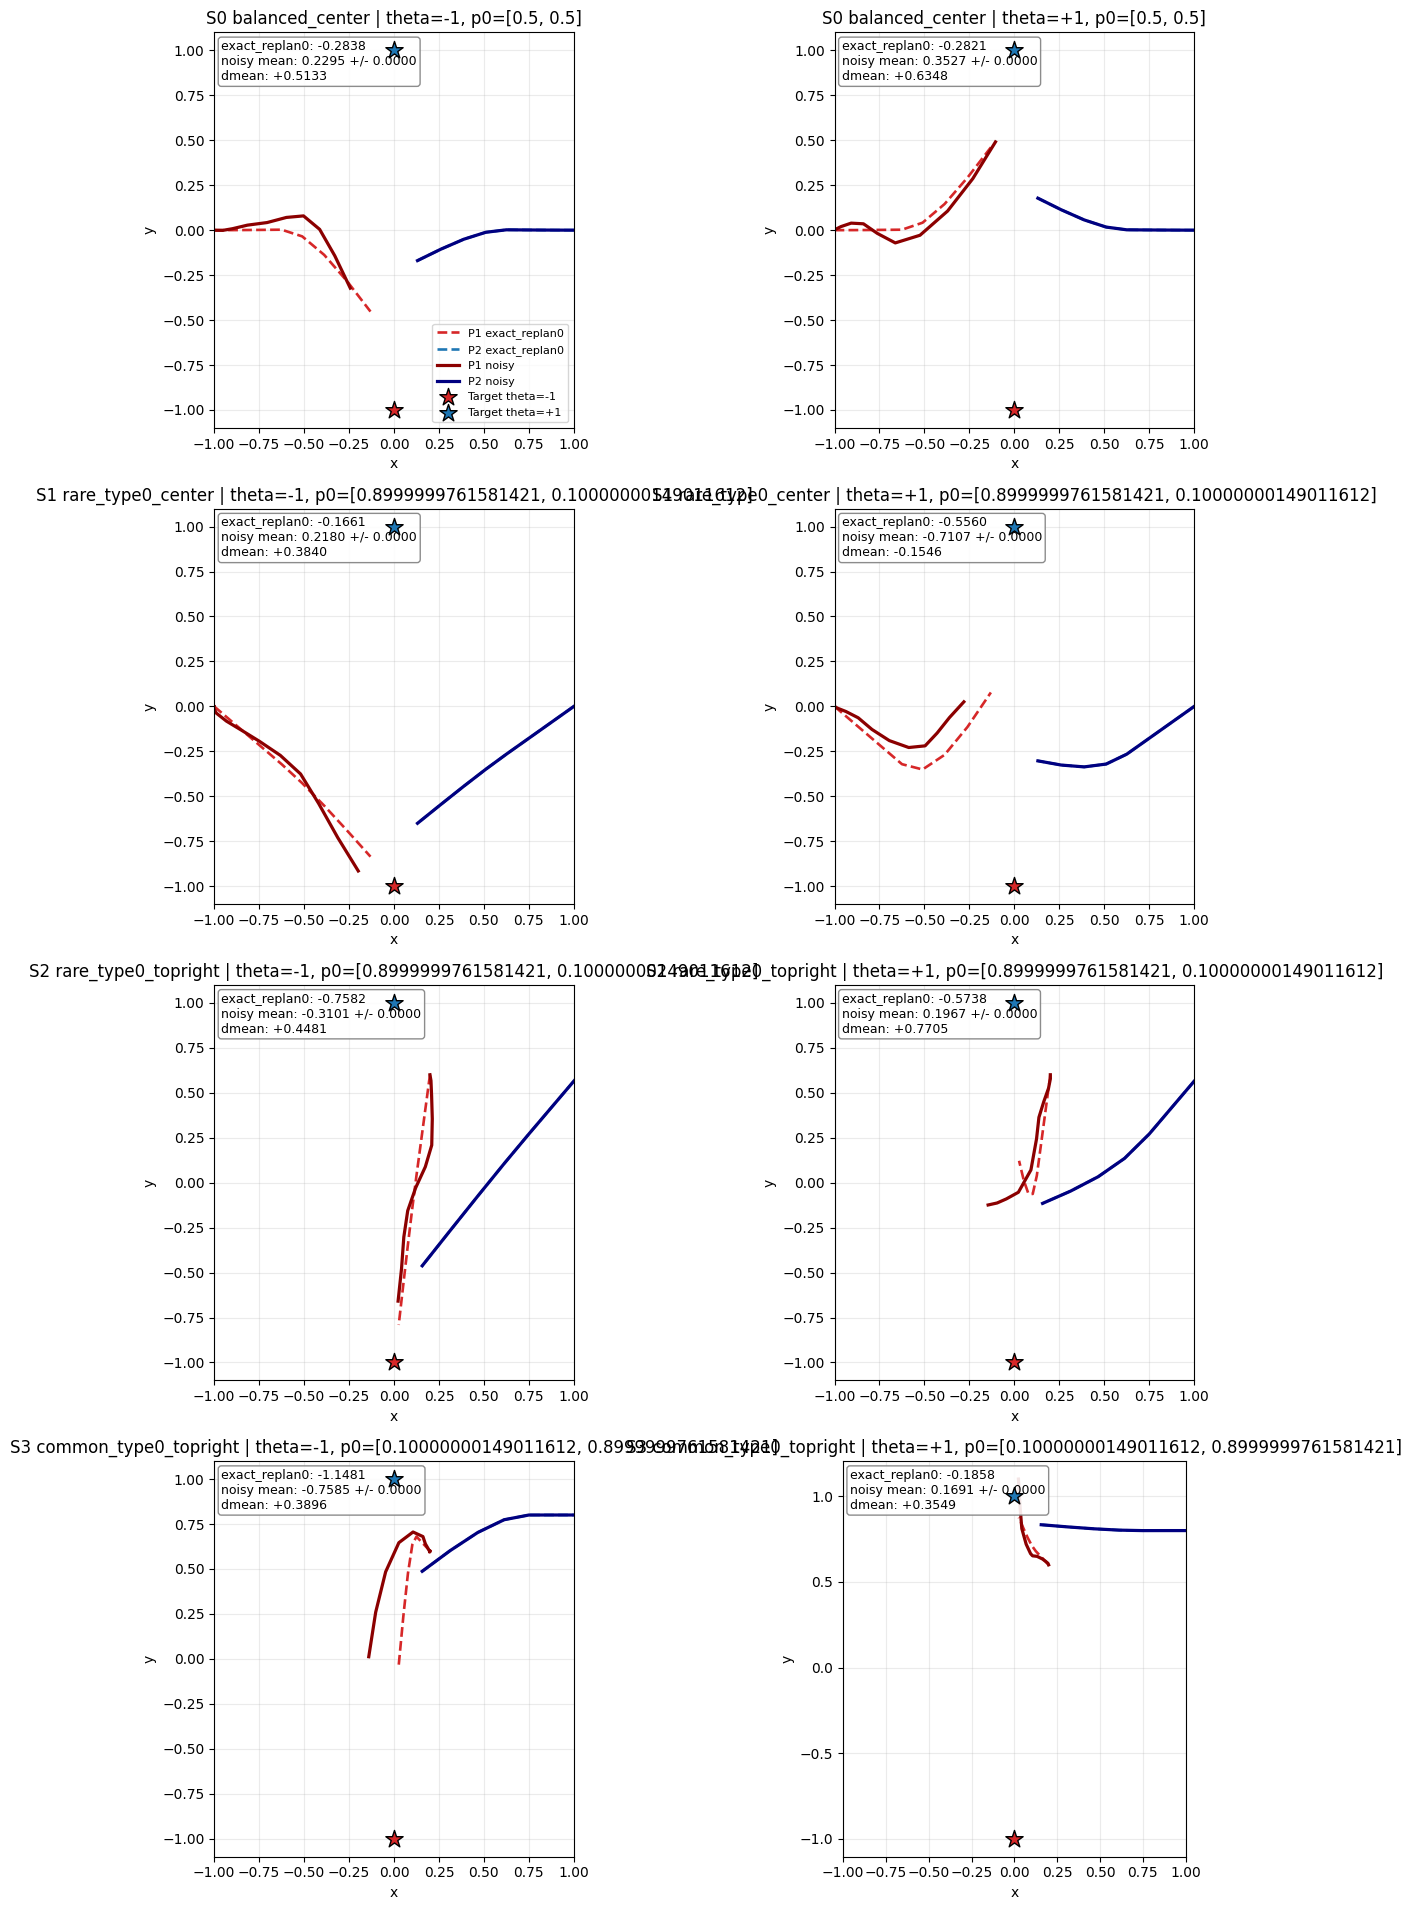

In [65]:

# Plot reference baseline vs one noisy trial (trial 0) for each scenario/type
ref_key = "exact_replan" if EXACT_REFERENCE == "replan" else "exact"
ref_name = "exact_replan0" if EXACT_REFERENCE == "replan" else "exact_existing"

num_rows = len(scenarios)
num_cols = game.I
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6.8 * num_cols, 4.8 * num_rows), squeeze=False)

targets = game.type_targets().detach().cpu().numpy()

for r, s in enumerate(scenarios):
    name = s["name"]
    prior_np = s["prior"].detach().cpu().numpy()

    for c in range(num_cols):
        ax = axes[r, c]
        ex = scenario_results[name][ref_key][c]
        no = scenario_results[name]["noisy_trials"][c][0]

        x_ex = ex["rollout"]["x_traj"].detach().cpu().numpy()
        x_no = no["x_traj"].detach().cpu().numpy()

        dx1 = game.cfg.dx1
        p1_ex = x_ex[:, :2]
        p2_ex = x_ex[:, dx1 : dx1 + 2]
        p1_no = x_no[:, :2]
        p2_no = x_no[:, dx1 : dx1 + 2]

        ax.plot(p1_ex[:, 0], p1_ex[:, 1], "--", color="tab:red", linewidth=1.9, label=(f"P1 {ref_name}" if (r == 0 and c == 0) else None))
        ax.plot(p2_ex[:, 0], p2_ex[:, 1], "--", color="tab:blue", linewidth=1.9, label=(f"P2 {ref_name}" if (r == 0 and c == 0) else None))

        ax.plot(p1_no[:, 0], p1_no[:, 1], "-", color="darkred", linewidth=2.3, label=("P1 noisy" if (r == 0 and c == 0) else None))
        ax.plot(p2_no[:, 0], p2_no[:, 1], "-", color="navy", linewidth=2.3, label=("P2 noisy" if (r == 0 and c == 0) else None))

        for i in range(game.I):
            ax.scatter(
                targets[i, 0],
                targets[i, 1],
                marker="*",
                s=170,
                color=("tab:red" if i == 0 else "tab:blue"),
                edgecolors="black",
                zorder=6,
                label=(f"Target theta={float(game.theta_vals[i]):+.0f}" if (r == 0 and c == 0) else None),
            )

        exact_cost = ex["cost"]
        mean_cost = scenario_results[name]["noisy_stats"][c]["mean"]
        std_cost = scenario_results[name]["noisy_stats"][c]["std"]

        ax.text(
            0.02,
            0.98,
            f"{ref_name}: {exact_cost:.4f}\n"
            f"noisy mean: {mean_cost:.4f} +/- {std_cost:.4f}\n"
            f"dmean: {mean_cost - exact_cost:+.4f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
        )

        ax.set_title(f"{name} | theta={float(game.theta_vals[c]):+.0f}, p0={prior_np.round(2).tolist()}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.25)
        ax.set_xlim([-1, 1])

        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()


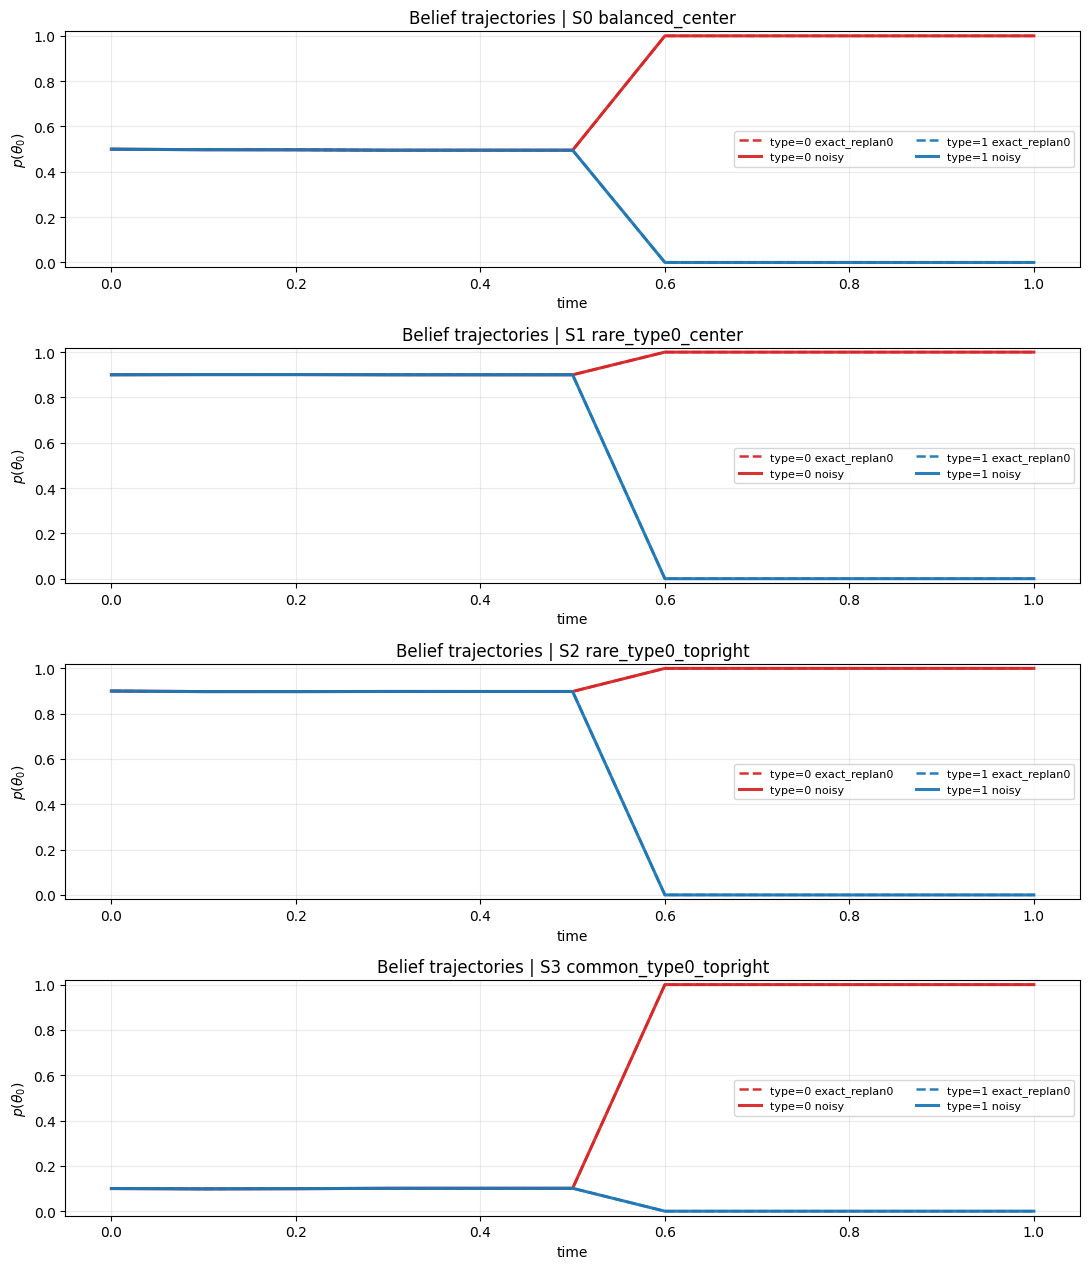

In [47]:

# Belief trajectories: reference baseline vs noisy trial 0 (p(theta_0))
ref_key = "exact_replan" if EXACT_REFERENCE == "replan" else "exact"
ref_name = "exact_replan0" if EXACT_REFERENCE == "replan" else "exact_existing"

fig, axes = plt.subplots(len(scenarios), 1, figsize=(11, 3.2 * len(scenarios)), squeeze=False)

for r, s in enumerate(scenarios):
    name = s["name"]
    ax = axes[r, 0]

    for type_idx, color in [(0, "tab:red"), (1, "tab:blue")]:
        b_ex = scenario_results[name][ref_key][type_idx]["rollout"]["belief_traj"].detach().cpu().numpy()
        b_no = scenario_results[name]["noisy_trials"][type_idx][0]["belief_traj"].detach().cpu().numpy()

        t_ex = np.linspace(0.0, float(game_cfg.T), b_ex.shape[0])
        t_no = np.linspace(0.0, float(game_cfg.T), b_no.shape[0])

        ax.plot(t_ex, b_ex[:, 0], "--", color=color, linewidth=1.8, alpha=0.95, label=f"type={type_idx} {ref_name}")
        ax.plot(t_no, b_no[:, 0], "-", color=color, linewidth=2.2, alpha=0.95, label=f"type={type_idx} noisy")

    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Belief trajectories | {name}")
    ax.set_xlabel("time")
    ax.set_ylabel(r"$p(\theta_0)$")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, ncol=2, loc="center right")

plt.tight_layout()
plt.show()


### Notes
- This notebook uses **re-solve every timestep** under noisy observation.
- Belief is updated by Bayes from the selected signaling branch.
- To increase statistical confidence, raise `NUM_NOISE_TRIALS`.
- To test stronger corruption, increase `OBS_NOISE_STD` or use `OBS_NOISE_MODE = "all"`.
- The rollout enforces exactly one re-solve per step (`num_replans == K`) and raises if violated.
- `exact` now uses the same one-shot `rollout_trajectory` path as the existing rollout notebooks.
- `exact_replan` is reported separately to sanity-check receding-horizon behavior at zero noise.
- Plot cells use `EXACT_REFERENCE` (default `"replan"`) so belief comparisons align with re-solve-every-step semantics.
- If belief does not move under noise, often `alpha` is effectively pooling at many steps.
- Per-step adaptation diagnostics are available in `step_diag_df` (`delta_loss`, `iters_run`, `converged`).
- Now each step solves on the remaining subtree by rebasing alpha along the realized path; unreachable nodes are dropped via the shorter indexer.
- At each step, remaining subtree logits are optimized online for `ONLINE_ALPHA_ITERS` before applying the root action.
- Per-step optimization diagnostics are available in `step_diag_df` and aggregated in `summary_df` step columns.
